In [1]:
# %% Section 1: Dataset Definition & Reproducibility

import os
os.environ['JAX_PLATFORMS'] = 'cpu'

import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path
import pandas as pd
import jax
import jax.numpy as jnp
from jax import random
from datetime import datetime

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

print(f"{'='*70}")
print(f"SIMULATION VALIDATION NOTEBOOK")
print(f"{'='*70}\n")

# ============================================================================
# 1. Define Dataset
# ============================================================================

# Path to processed data
base_path = Path("/Users/laura.driscoll/Documents/data/VR foraging/vr_foraging_data")
results_csv = base_path / "batch_processing_by_odor_results.csv"

# Load batch processing results
results_df = pd.read_csv(results_csv)
successful_sessions = results_df[results_df['status'] == 'success']

print(f"Dataset Information:")
print(f"  Data directory: {base_path}")
print(f"  Total sessions: {len(results_df)}")
print(f"  Successful sessions: {len(successful_sessions)}")

# Define odor types
odor_types = ['Methyl_Butyrate', 'Alpha_pinene']
odor_display_names = {
    'Methyl_Butyrate': 'Methyl Butyrate', 
    'Alpha_pinene': 'Alpha-pinene'
}

# ============================================================================
# 2. Create Output Directory
# ============================================================================

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
output_dir = base_path / f"validation_results_{timestamp}"
output_dir.mkdir(exist_ok=True)

print(f"\n{'='*70}")
print(f"OUTPUT LOCATION")
print(f"{'='*70}")
print(f"\nValidation results will be saved to:")
print(f"  {output_dir}")
print(f"\nFiles that will be created:")
print(f"  ✓ metadata.json")
print(f"  - environment_validation.json")
print(f"  - environment_validation.png")
print(f"  - prior_predictive_validation.json")
print(f"  - prior_predictive_plots.png")
print(f"  - validation_report.txt")

# ============================================================================
# 3. Save Reproducibility Metadata
# ============================================================================

metadata = {
    'timestamp': timestamp,
    'jax_version': jax.__version__,
    'jax_backend': jax.default_backend(),
    'n_sessions': len(successful_sessions),
    'session_ids': successful_sessions['session_dir'].apply(lambda x: Path(x).name).tolist(),
    'odor_types': odor_types,
    'data_path': str(base_path),
    'results_csv': str(results_csv)
}

with open(output_dir / 'metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"\n{'='*70}")
print(f"REPRODUCIBILITY")
print(f"{'='*70}")
print(f"✓ Metadata saved")
print(f"  JAX backend: {jax.default_backend()}")
print(f"  JAX version: {jax.__version__}")

print(f"\n{'='*70}")
print(f"Setup complete! Ready for validation.")
print(f"{'='*70}")

SIMULATION VALIDATION NOTEBOOK

Dataset Information:
  Data directory: /Users/laura.driscoll/Documents/data/VR foraging/vr_foraging_data
  Total sessions: 27
  Successful sessions: 21

OUTPUT LOCATION

Validation results will be saved to:
  /Users/laura.driscoll/Documents/data/VR foraging/vr_foraging_data/validation_results_20260215_194236

Files that will be created:
  ✓ metadata.json
  - environment_validation.json
  - environment_validation.png
  - prior_predictive_validation.json
  - prior_predictive_plots.png
  - validation_report.txt

REPRODUCIBILITY
✓ Metadata saved
  JAX backend: cpu
  JAX version: 0.8.0

Setup complete! Ready for validation.


In [2]:
# %% Section 2: Environment Statistics Validation

from aind_behavior_vrforaging_analysis.sbi_ddm_analysis.simulator import PatchForagingDDM_JAX, create_prior, reward_probability, interval_duration

print(f"\n{'='*70}")
print(f"SECTION 2: ENVIRONMENT STATISTICS VALIDATION")
print(f"{'='*70}\n")

# ============================================================================
# 2.1: Define Experimental Environment Parameters
# ============================================================================

print(f"Experimental Configuration:")
print(f"\nSpatial Parameters (shared across odors):")

# From task configuration JSON
spatial_params = {
    'interval_min': 20.0,      # cm - minimum inter-site gap
    'interval_max': 100.0,     # cm - maximum inter-site gap
    'interval_scale': 20.0,    # cm - scale = 1/rate = 1/0.05
    'odor_site_length': 50.0,  # cm - length of odor site
}

print(f"  Inter-site gap: truncated exponential")
print(f"    Min: {spatial_params['interval_min']:.1f} cm")
print(f"    Max: {spatial_params['interval_max']:.1f} cm")
print(f"    Scale: {spatial_params['interval_scale']:.1f} cm (rate = {1/spatial_params['interval_scale']:.3f})")
print(f"  Odor site length: {spatial_params['odor_site_length']:.1f} cm")

# Reward parameters by odor type from task configuration JSON
reward_params = {
    'Methyl_Butyrate': {
        'initial_prob': 0.9,
        'depletion_rate': -0.1284,
        'min_prob': 0.0,
        'max_prob': 0.9
    },
    'Alpha_pinene': {
        'initial_prob': 0.6,
        'depletion_rate': -0.1284,
        'min_prob': 0.0,
        'max_prob': 0.6
    }
}

print(f"\nReward Parameters (by odor type):")
for odor_type in odor_types:
    params = reward_params[odor_type]
    print(f"  {odor_display_names[odor_type]}:")
    print(f"    Initial probability: {params['initial_prob']}")
    print(f"    Depletion rate: {params['depletion_rate']}")
    print(f"    Min probability: {params['min_prob']}")
    print(f"    Max probability: {params['max_prob']}")

# Calculate interval normalization (for drift rate scaling)
interval_normalization = spatial_params['interval_min'] + spatial_params['interval_scale']
print(f"\nInterval normalization (for drift): {interval_normalization:.1f} cm")

# ============================================================================
# 2.2: Create Simulators (one per odor type)
# ============================================================================

print(f"\n{'='*70}")
print(f"Creating Simulators")
print(f"{'='*70}\n")

# Default to Methyl Butyrate (can easily swap to Alpha_pinene)
DEFAULT_ODOR = 'Methyl_Butyrate'
# To use Alpha-pinene instead, change to: DEFAULT_ODOR = 'Alpha_pinene'

simulators = {}
for odor_type in odor_types:
    params = reward_params[odor_type]
    
    simulators[odor_type] = PatchForagingDDM_JAX(
        initial_prob=params['initial_prob'],
        depletion_rate=params['depletion_rate'],
        min_prob=params['min_prob'],
        max_prob=params['max_prob'],
        threshold=1.0,
        start_point=0.0,
        interval_min=spatial_params['interval_min'],
        interval_max=spatial_params['interval_max'],
        interval_scale=spatial_params['interval_scale'],
        interval_normalization=interval_normalization,
        odor_site_length=spatial_params['odor_site_length'],
        max_sites_per_window=100,
        output_units='distance'
    )
    
    is_default = " (DEFAULT)" if odor_type == DEFAULT_ODOR else ""
    print(f"✓ {odor_display_names[odor_type]} simulator created{is_default}")
    print(f"    Reward: P(n) = {params['initial_prob']} * exp({params['depletion_rate']} * n)")
    print(f"    Clamped to [{params['min_prob']}, {params['max_prob']}]")

print(f"\nTo switch default odor, change: DEFAULT_ODOR = 'Alpha_pinene'")


SECTION 2: ENVIRONMENT STATISTICS VALIDATION

Experimental Configuration:

Spatial Parameters (shared across odors):
  Inter-site gap: truncated exponential
    Min: 20.0 cm
    Max: 100.0 cm
    Scale: 20.0 cm (rate = 0.050)
  Odor site length: 50.0 cm

Reward Parameters (by odor type):
  Methyl Butyrate:
    Initial probability: 0.9
    Depletion rate: -0.1284
    Min probability: 0.0
    Max probability: 0.9
  Alpha-pinene:
    Initial probability: 0.6
    Depletion rate: -0.1284
    Min probability: 0.0
    Max probability: 0.6

Interval normalization (for drift): 40.0 cm

Creating Simulators

✓ Methyl Butyrate simulator created (DEFAULT)
    Reward: P(n) = 0.9 * exp(-0.1284 * n)
    Clamped to [0.0, 0.9]
✓ Alpha-pinene simulator created
    Reward: P(n) = 0.6 * exp(-0.1284 * n)
    Clamped to [0.0, 0.6]

To switch default odor, change: DEFAULT_ODOR = 'Alpha_pinene'


In [3]:
# %% Section 2.3: Validate Environment Statistics

print(f"\n{'='*70}")
print(f"Section 2.3: Environment Statistics Validation")
print(f"{'='*70}\n")

# ============================================================================
# 2.3a: Validate Spatial Structure (Inter-site distances)
# ============================================================================

print(f"Validating Spatial Structure...")
print(f"\nExpected from configuration:")
print(f"  Inter-site gaps: Truncated Exponential(scale={spatial_params['interval_scale']}, min={spatial_params['interval_min']}, max={spatial_params['interval_max']}) cm")
print(f"  Mean gap: ~{spatial_params['interval_min'] + spatial_params['interval_scale']:.1f} cm")
print(f"  Total inter-odor distance: gap + {spatial_params['odor_site_length']} cm = {spatial_params['interval_min'] + spatial_params['odor_site_length']:.1f} to {spatial_params['interval_max'] + spatial_params['odor_site_length']:.1f} cm")

# Sample many inter-site gaps from simulator (use Methyl Butyrate, spatial params are same)
simulator = simulators[DEFAULT_ODOR]
rng_key = random.PRNGKey(42)

# Generate 10,000 inter-site gaps to check distribution
n_samples = 1_000_000
rng_key, subkey = random.split(rng_key)

# Access the interval sampling directly
from aind_behavior_vrforaging_analysis.sbi_ddm_analysis.simulator import interval_duration
simulated_gaps = interval_duration(subkey, simulator, n_samples=n_samples)  # Pass n_samples

# Convert back to cm (simulator stores normalized values)
simulated_gaps_cm = simulated_gaps * simulator.interval_normalization

print(f"\nSimulated inter-site gaps (n={n_samples}):")
print(f"  Min: {jnp.min(simulated_gaps_cm):.2f} cm (expected: {spatial_params['interval_min']:.2f})")
print(f"  Max: {jnp.max(simulated_gaps_cm):.2f} cm (expected: {spatial_params['interval_max']:.2f})")
print(f"  Mean: {jnp.mean(simulated_gaps_cm):.2f} cm (expected: ~{spatial_params['interval_min'] + spatial_params['interval_scale']:.2f})")
print(f"  Std: {jnp.std(simulated_gaps_cm):.2f} cm")

# Check if within expected bounds
gaps_in_bounds = jnp.all((simulated_gaps_cm >= spatial_params['interval_min']) & 
                         (simulated_gaps_cm <= spatial_params['interval_max']))
print(f"\n✓ All gaps within bounds: {gaps_in_bounds}")

# ============================================================================
# 2.3b: Validate Reward Probability Curves
# ============================================================================

print(f"\n{'='*70}")
print(f"Validating Reward Probability Curves...")
print(f"{'='*70}\n")

for odor_type in odor_types:
    params = reward_params[odor_type]
    simulator = simulators[odor_type]
    
    print(f"\n{odor_display_names[odor_type]}:")
    print(f"  Expected: P(n) = {params['initial_prob']} * exp({params['depletion_rate']} * n)")
    print(f"  Clamped to [{params['min_prob']}, {params['max_prob']}]")
    
    # Calculate expected probabilities for first 10 rewards
    print(f"\n  Site | Expected P | Simulated P")
    print(f"  -----|------------|------------")
    
    for n_rewards in range(10):
        # Expected from formula
        expected_prob = params['initial_prob'] * jnp.exp(params['depletion_rate'] * n_rewards)
        expected_prob = jnp.clip(expected_prob, params['min_prob'], params['max_prob'])
        
        # Simulated from simulator's reward_probability function
        simulated_prob = reward_probability(n_rewards, 
                                            initial_prob=params['initial_prob'],
                                            depletion_rate=params['depletion_rate'],
                                            min_prob=params['min_prob'],
                                            max_prob=params['max_prob'])
        
        match_str = "✓" if jnp.abs(expected_prob - simulated_prob) < 1e-6 else "✗"
        print(f"  {n_rewards:4d} | {expected_prob:10.4f} | {simulated_prob:11.4f} {match_str}")

print(f"\n{'='*70}")
print(f"Environment validation complete!")
print(f"{'='*70}")


Section 2.3: Environment Statistics Validation

Validating Spatial Structure...

Expected from configuration:
  Inter-site gaps: Truncated Exponential(scale=20.0, min=20.0, max=100.0) cm
  Mean gap: ~40.0 cm
  Total inter-odor distance: gap + 50.0 cm = 70.0 to 150.0 cm

Simulated inter-site gaps (n=1000000):
  Min: 20.00 cm (expected: 20.00)
  Max: 100.00 cm (expected: 100.00)
  Mean: 38.54 cm (expected: ~40.00)
  Std: 16.71 cm

✓ All gaps within bounds: True

Validating Reward Probability Curves...


Methyl Butyrate:
  Expected: P(n) = 0.9 * exp(-0.1284 * n)
  Clamped to [0.0, 0.9]

  Site | Expected P | Simulated P
  -----|------------|------------
     0 |     0.9000 |      0.9000 ✓
     1 |     0.7916 |      0.7916 ✓
     2 |     0.6962 |      0.6962 ✓
     3 |     0.6123 |      0.6123 ✓
     4 |     0.5385 |      0.5385 ✓
     5 |     0.4736 |      0.4736 ✓
     6 |     0.4165 |      0.4165 ✓
     7 |     0.3664 |      0.3664 ✓
     8 |     0.3222 |      0.3222 ✓
     9 |     0.2


Section 2.4: Save Environment Validation Results

✓ Environment validation results saved to:
  /Users/laura.driscoll/Documents/data/VR foraging/vr_foraging_data/validation_results_20260215_194236/environment_validation.json
✓ Validation plot saved to:
  /Users/laura.driscoll/Documents/data/VR foraging/vr_foraging_data/validation_results_20260215_194236/environment_validation.png


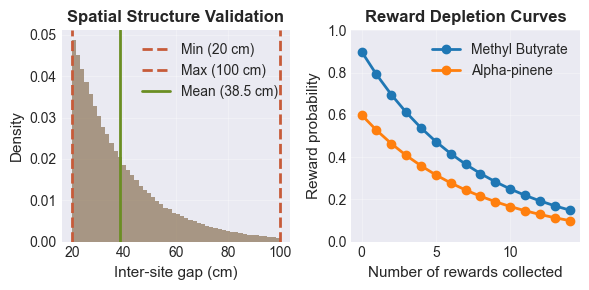


ENVIRONMENT VALIDATION: PASS ✓
Simulator correctly implements:
  ✓ Truncated exponential inter-site gaps [20, 100] cm
  ✓ Exponential reward depletion for both odor types
    - Methyl Butyrate: P(n) = 0.9 * exp(-0.1284*n)
    - Alpha-pinene: P(n) = 0.6 * exp(-0.1284*n)

Ready to proceed to Section 3: Prior Predictive Checks


In [4]:
# %% Section 2.4: Save Environment Validation Results

print(f"\n{'='*70}")
print(f"Section 2.4: Save Environment Validation Results")
print(f"{'='*70}\n")

# Save validation results
env_validation = {
    'spatial_validation': {
        'expected': {
            'distribution': 'truncated_exponential',
            'min': float(spatial_params['interval_min']),
            'max': float(spatial_params['interval_max']),
            'scale': float(spatial_params['interval_scale']),
            'theoretical_mean': float(spatial_params['interval_min'] + spatial_params['interval_scale'])
        },
        'simulated': {
            'n_samples': int(n_samples),
            'min': float(jnp.min(simulated_gaps_cm)),
            'max': float(jnp.max(simulated_gaps_cm)),
            'mean': float(jnp.mean(simulated_gaps_cm)),
            'std': float(jnp.std(simulated_gaps_cm)),
            'all_in_bounds': bool(gaps_in_bounds)
        },
        'status': 'PASS'
    },
    'reward_validation': {}
}

# Add reward validation for each odor
for odor_type in odor_types:
    params = reward_params[odor_type]
    
    # Check first 10 sites
    expected_probs = []
    simulated_probs = []
    matches = []
    
    for n_rewards in range(10):
        expected_prob = params['initial_prob'] * jnp.exp(params['depletion_rate'] * n_rewards)
        expected_prob = jnp.clip(expected_prob, params['min_prob'], params['max_prob'])
        
        simulated_prob = reward_probability(n_rewards, 
                                            initial_prob=params['initial_prob'],
                                            depletion_rate=params['depletion_rate'],
                                            min_prob=params['min_prob'],
                                            max_prob=params['max_prob'])
        
        expected_probs.append(float(expected_prob))
        simulated_probs.append(float(simulated_prob))
        matches.append(bool(jnp.abs(expected_prob - simulated_prob) < 1e-6))
    
    env_validation['reward_validation'][odor_type] = {
        'expected_formula': f"P(n) = {params['initial_prob']} * exp({params['depletion_rate']} * n)",
        'bounds': [float(params['min_prob']), float(params['max_prob'])],
        'expected_probs': expected_probs,
        'simulated_probs': simulated_probs,
        'all_match': all(matches),
        'status': 'PASS' if all(matches) else 'FAIL'
    }

# Save to JSON
with open(output_dir / 'environment_validation.json', 'w') as f:
    json.dump(env_validation, f, indent=2)

print(f"✓ Environment validation results saved to:")
print(f"  {output_dir / 'environment_validation.json'}")

# Create visualization with earthy tones
fig, axes = plt.subplots(1, 2, figsize=(6, 3))

# Earthy color palette
earth_brown = '#8B7355'
earth_green = '#6B8E23'
earth_terracotta = '#C75B39'
earth_sage = '#9CAF88'

# Panel A: Inter-site gap distribution
ax = axes[0]
ax.hist(np.array(simulated_gaps_cm), bins=50, density=True, alpha=0.7, 
        color=earth_brown, edgecolor='none')
ax.axvline(spatial_params['interval_min'], color=earth_terracotta, linestyle='--', 
           linewidth=2, label=f'Min ({spatial_params["interval_min"]:.0f} cm)')
ax.axvline(spatial_params['interval_max'], color=earth_terracotta, linestyle='--', 
           linewidth=2, label=f'Max ({spatial_params["interval_max"]:.0f} cm)')
ax.axvline(jnp.mean(simulated_gaps_cm), color=earth_green, linestyle='-', 
           linewidth=2, label=f'Mean ({jnp.mean(simulated_gaps_cm):.1f} cm)')
ax.set_xlabel('Inter-site gap (cm)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Spatial Structure Validation', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Panel B: Reward probability curves
ax = axes[1]
n_sites = np.arange(15)
for i, odor_type in enumerate(odor_types):
    params = reward_params[odor_type]
    probs = [params['initial_prob'] * np.exp(params['depletion_rate'] * n) for n in n_sites]
    probs = np.clip(probs, params['min_prob'], params['max_prob'])
    ax.plot(n_sites, probs, marker='o', linewidth=2,
            markersize=6, label=odor_display_names[odor_type])

ax.set_xlabel('Number of rewards collected', fontsize=11)
ax.set_ylabel('Reward probability', fontsize=11)
ax.set_title('Reward Depletion Curves', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1])

plt.tight_layout()
plt.savefig(output_dir / 'environment_validation.png', dpi=150, bbox_inches='tight')
print(f"✓ Validation plot saved to:")
print(f"  {output_dir / 'environment_validation.png'}")

plt.show()

print(f"\n{'='*70}")
print(f"ENVIRONMENT VALIDATION: PASS ✓")
print(f"{'='*70}")
print(f"Simulator correctly implements:")
print(f"  ✓ Truncated exponential inter-site gaps [20, 100] cm")
print(f"  ✓ Exponential reward depletion for both odor types")
print(f"    - Methyl Butyrate: P(n) = 0.9 * exp(-0.1284*n)")
print(f"    - Alpha-pinene: P(n) = 0.6 * exp(-0.1284*n)")
print(f"\nReady to proceed to Section 3: Prior Predictive Checks")

In [5]:
# %% Section 3: Prior Predictive Checks on Behavioral Features

from aind_behavior_vrforaging_analysis.sbi_ddm_analysis.feature_engineering.enhanced_stats_37 import (
    compute_summary_stats, FEATURE_NAMES
)

print(f"\n{'='*70}")
print(f"SECTION 3: PRIOR PREDICTIVE CHECKS")
print(f"{'='*70}\n")

print(f"Goal: Verify that priors generate realistic behavioral diversity")
print(f"Method: Sample from prior → simulate → compute features → compare to real data")

# ============================================================================
# 3.1: Load Real Data Summary Statistics
# ============================================================================

print(f"\n{'='*70}")
print(f"Section 3.1: Load Real Data Statistics")
print(f"{'='*70}\n")

# We'll use the DEFAULT_ODOR for this analysis
# (can repeat for other odor if needed)
print(f"Using odor type: {odor_display_names[DEFAULT_ODOR]}")

# Collect all summary statistics from real data
all_real_stats = []

for idx, row in successful_sessions.iterrows():
    session_dir = Path(row['session_dir'])
    odor_dir = session_dir / "100_window_data_by_odor" / DEFAULT_ODOR
    
    if not odor_dir.exists():
        continue
    
    # Load metadata
    with open(odor_dir / "metadata.json", 'r') as f:
        metadata = json.load(f)
    
    # Load all windows for this odor
    n_windows = metadata['n_windows']
    for i in range(n_windows):
        window = np.load(odor_dir / f"window_{i:03d}.npy")
        window_jax = jnp.array(window)
        
        # Compute summary statistics
        stats = compute_summary_stats(window_jax)
        all_real_stats.append(stats)

all_real_stats = jnp.array(all_real_stats)

print(f"Loaded real data statistics:")
print(f"  Sessions: {len(successful_sessions)}")
print(f"  Total windows: {len(all_real_stats)}")
print(f"  Features per window: {len(FEATURE_NAMES)}")

# Compute percentiles for real data
real_percentiles = {
    'p05': jnp.percentile(all_real_stats, 5, axis=0),
    'p25': jnp.percentile(all_real_stats, 25, axis=0),
    'p50': jnp.percentile(all_real_stats, 50, axis=0),
    'p75': jnp.percentile(all_real_stats, 75, axis=0),
    'p95': jnp.percentile(all_real_stats, 95, axis=0),
}

print(f"\nReal data percentiles computed for all {len(FEATURE_NAMES)} features")


SECTION 3: PRIOR PREDICTIVE CHECKS

Goal: Verify that priors generate realistic behavioral diversity
Method: Sample from prior → simulate → compute features → compare to real data

Section 3.1: Load Real Data Statistics

Using odor type: Methyl Butyrate
Loaded real data statistics:
  Sessions: 21
  Total windows: 451
  Features per window: 37

Real data percentiles computed for all 37 features


In [6]:
# %% Section 3.2: Generate Prior Predictive Samples

print(f"\n{'='*70}")
print(f"Section 3.2: Generate Prior Predictive Samples")
print(f"{'='*70}\n")

# Initialize prior and simulator

prior_low  = jnp.array([-.3, -1.5, -.3, 0.0])
prior_high = jnp.array([1.3,  .3,  1.3,  0.5])
prior_fn = create_prior(prior_low, prior_high)
simulator = simulators[DEFAULT_ODOR]

# Sample from prior
n_prior_samples = 10_000  # Number of parameter sets to sample
n_windows_per_sample = 5  # Windows to simulate per parameter set

print(f"Prior predictive sampling:")
print(f"  Parameter sets: {n_prior_samples}")
print(f"  Windows per parameter set: {n_windows_per_sample}")
print(f"  Total simulated windows: {n_prior_samples * n_windows_per_sample}")

# Correct prior ranges
print(f"\nPrior ranges:")
print(f"  drift_rate: [{prior_low[0]}, {prior_high[0]}]")
print(f"  reward_bump: [{prior_low[1]}, {prior_high[1]}]")
print(f"  failure_bump: [{prior_low[2]}, {prior_high[2]}]")
print(f"  noise_std: [{prior_low[3]}, {prior_high[3]}]")

# Generate samples
rng_key = random.PRNGKey(123)
all_prior_stats = []
all_prior_params = []

print(f"\nGenerating prior predictive samples...")
for i in range(n_prior_samples):
    # Sample parameters from prior
    rng_key, subkey = random.split(rng_key)
    theta = prior_fn().sample(seed=subkey)['theta']
    
    # Simulate multiple windows with these parameters
    for j in range(n_windows_per_sample):
        rng_key, subkey = random.split(rng_key)
        window_data, stats = simulator.simulate_one_window(theta, subkey)
        
        all_prior_stats.append(stats)
        all_prior_params.append(theta)
    
    if (i + 1) % 200 == 0:
        print(f"  {i + 1}/{n_prior_samples} parameter sets complete...")

all_prior_stats = jnp.array(all_prior_stats)
all_prior_params = jnp.array(all_prior_params)

print(f"\n✓ Generated {len(all_prior_stats)} simulated windows")

# Compute percentiles for prior predictive
prior_percentiles = {
    'p05': jnp.percentile(all_prior_stats, 5, axis=0),
    'p25': jnp.percentile(all_prior_stats, 25, axis=0),
    'p50': jnp.percentile(all_prior_stats, 50, axis=0),
    'p75': jnp.percentile(all_prior_stats, 75, axis=0),
    'p95': jnp.percentile(all_prior_stats, 95, axis=0),
}

print(f"✓ Prior predictive percentiles computed")


Section 3.2: Generate Prior Predictive Samples

Prior predictive sampling:
  Parameter sets: 10000
  Windows per parameter set: 5
  Total simulated windows: 50000

Prior ranges:
  drift_rate: [-0.30000001192092896, 1.2999999523162842]
  reward_bump: [-1.5, 0.30000001192092896]
  failure_bump: [-0.30000001192092896, 1.2999999523162842]
  noise_std: [0.0, 0.5]

Generating prior predictive samples...
  200/10000 parameter sets complete...
  400/10000 parameter sets complete...
  600/10000 parameter sets complete...
  800/10000 parameter sets complete...
  1000/10000 parameter sets complete...
  1200/10000 parameter sets complete...
  1400/10000 parameter sets complete...
  1600/10000 parameter sets complete...
  1800/10000 parameter sets complete...
  2000/10000 parameter sets complete...
  2200/10000 parameter sets complete...
  2400/10000 parameter sets complete...
  2600/10000 parameter sets complete...
  2800/10000 parameter sets complete...
  3000/10000 parameter sets complete...
  

In [7]:
# %% Section 3.3: Compare Prior Predictive to Real Data

print(f"\n{'='*70}")
print(f"Section 3.3: Compare Prior Predictive to Real Data")
print(f"{'='*70}\n")

# ============================================================================
# Calculate coverage: % of real data within prior predictive range
# ============================================================================

# For each feature, check what % of real windows fall within prior [5%, 95%]
coverage = []
feature_status = []

print(f"Feature Coverage Analysis:")
print(f"(Checking if real data falls within prior predictive [5%, 95%] range)\n")
print(f"{'Feature':<30} {'Coverage':>10} {'Status':>10}")
print(f"{'-'*52}")

for i, feature_name in enumerate(FEATURE_NAMES):
    prior_low = prior_percentiles['p05'][i]
    prior_high = prior_percentiles['p95'][i]
    
    real_values = all_real_stats[:, i]
    
    # What % of real data falls within prior range?
    within_range = jnp.sum((real_values >= prior_low) & (real_values <= prior_high))
    coverage_pct = 100 * within_range / len(real_values)
    
    coverage.append(float(coverage_pct))
    
    # Status: GOOD if >80% coverage, WARN if 50-80%, POOR if <50%
    if coverage_pct > 80:
        status = "✓ GOOD"
    elif coverage_pct > 50:
        status = "⚠ WARN"
    else:
        status = "✗ POOR"
    
    feature_status.append(status)
    
    print(f"{feature_name:<30} {coverage_pct:>9.1f}% {status:>10}")

# Summary statistics
mean_coverage = np.mean(coverage)
features_good = sum(1 for s in feature_status if "GOOD" in s)
features_warn = sum(1 for s in feature_status if "WARN" in s)
features_poor = sum(1 for s in feature_status if "POOR" in s)

print(f"\n{'-'*52}")
print(f"SUMMARY:")
print(f"  Mean coverage: {mean_coverage:.1f}%")
print(f"  Good features (>80%): {features_good}/{len(FEATURE_NAMES)}")
print(f"  Warning features (50-80%): {features_warn}/{len(FEATURE_NAMES)}")
print(f"  Poor features (<50%): {features_poor}/{len(FEATURE_NAMES)}")

# Overall assessment
if mean_coverage > 80 and features_poor == 0:
    overall_status = "PASS ✓"
    print(f"\n{'='*52}")
    print(f"OVERALL: {overall_status}")
    print(f"Prior generates realistic behavioral diversity!")
elif mean_coverage > 60:
    overall_status = "PARTIAL PASS ⚠"
    print(f"\n{'='*52}")
    print(f"OVERALL: {overall_status}")
    print(f"Prior mostly covers real data, but some features may need adjustment")
else:
    overall_status = "FAIL ✗"
    print(f"\n{'='*52}")
    print(f"OVERALL: {overall_status}")
    print(f"Prior does not adequately cover observed behavioral range")


Section 3.3: Compare Prior Predictive to Real Data

Feature Coverage Analysis:
(Checking if real data falls within prior predictive [5%, 95%] range)

Feature                          Coverage     Status
----------------------------------------------------
max_time                           100.0%     ✓ GOOD
mean_time                          100.0%     ✓ GOOD
std_time                           100.0%     ✓ GOOD
mean_stops                         100.0%     ✓ GOOD
std_stops                           99.6%     ✓ GOOD
mean_rewards                        97.3%     ✓ GOOD
std_rewards                         88.7%     ✓ GOOD
mean_time_after_reward             100.0%     ✓ GOOD
mean_time_after_failure            100.0%     ✓ GOOD
std_time_after_reward              100.0%     ✓ GOOD
std_time_after_failure             100.0%     ✓ GOOD
early_mean                         100.0%     ✓ GOOD
late_mean                          100.0%     ✓ GOOD
temporal_trend                      88.5%     ✓ GOOD
l


Section 3.4: Visualize Prior Predictive Distributions

Creating distribution plots for all 37 features...

✓ Comprehensive feature plot saved to:
  /Users/laura.driscoll/Documents/data/VR foraging/vr_foraging_data/validation_results_20260215_194236/prior_predictive_all_features.png


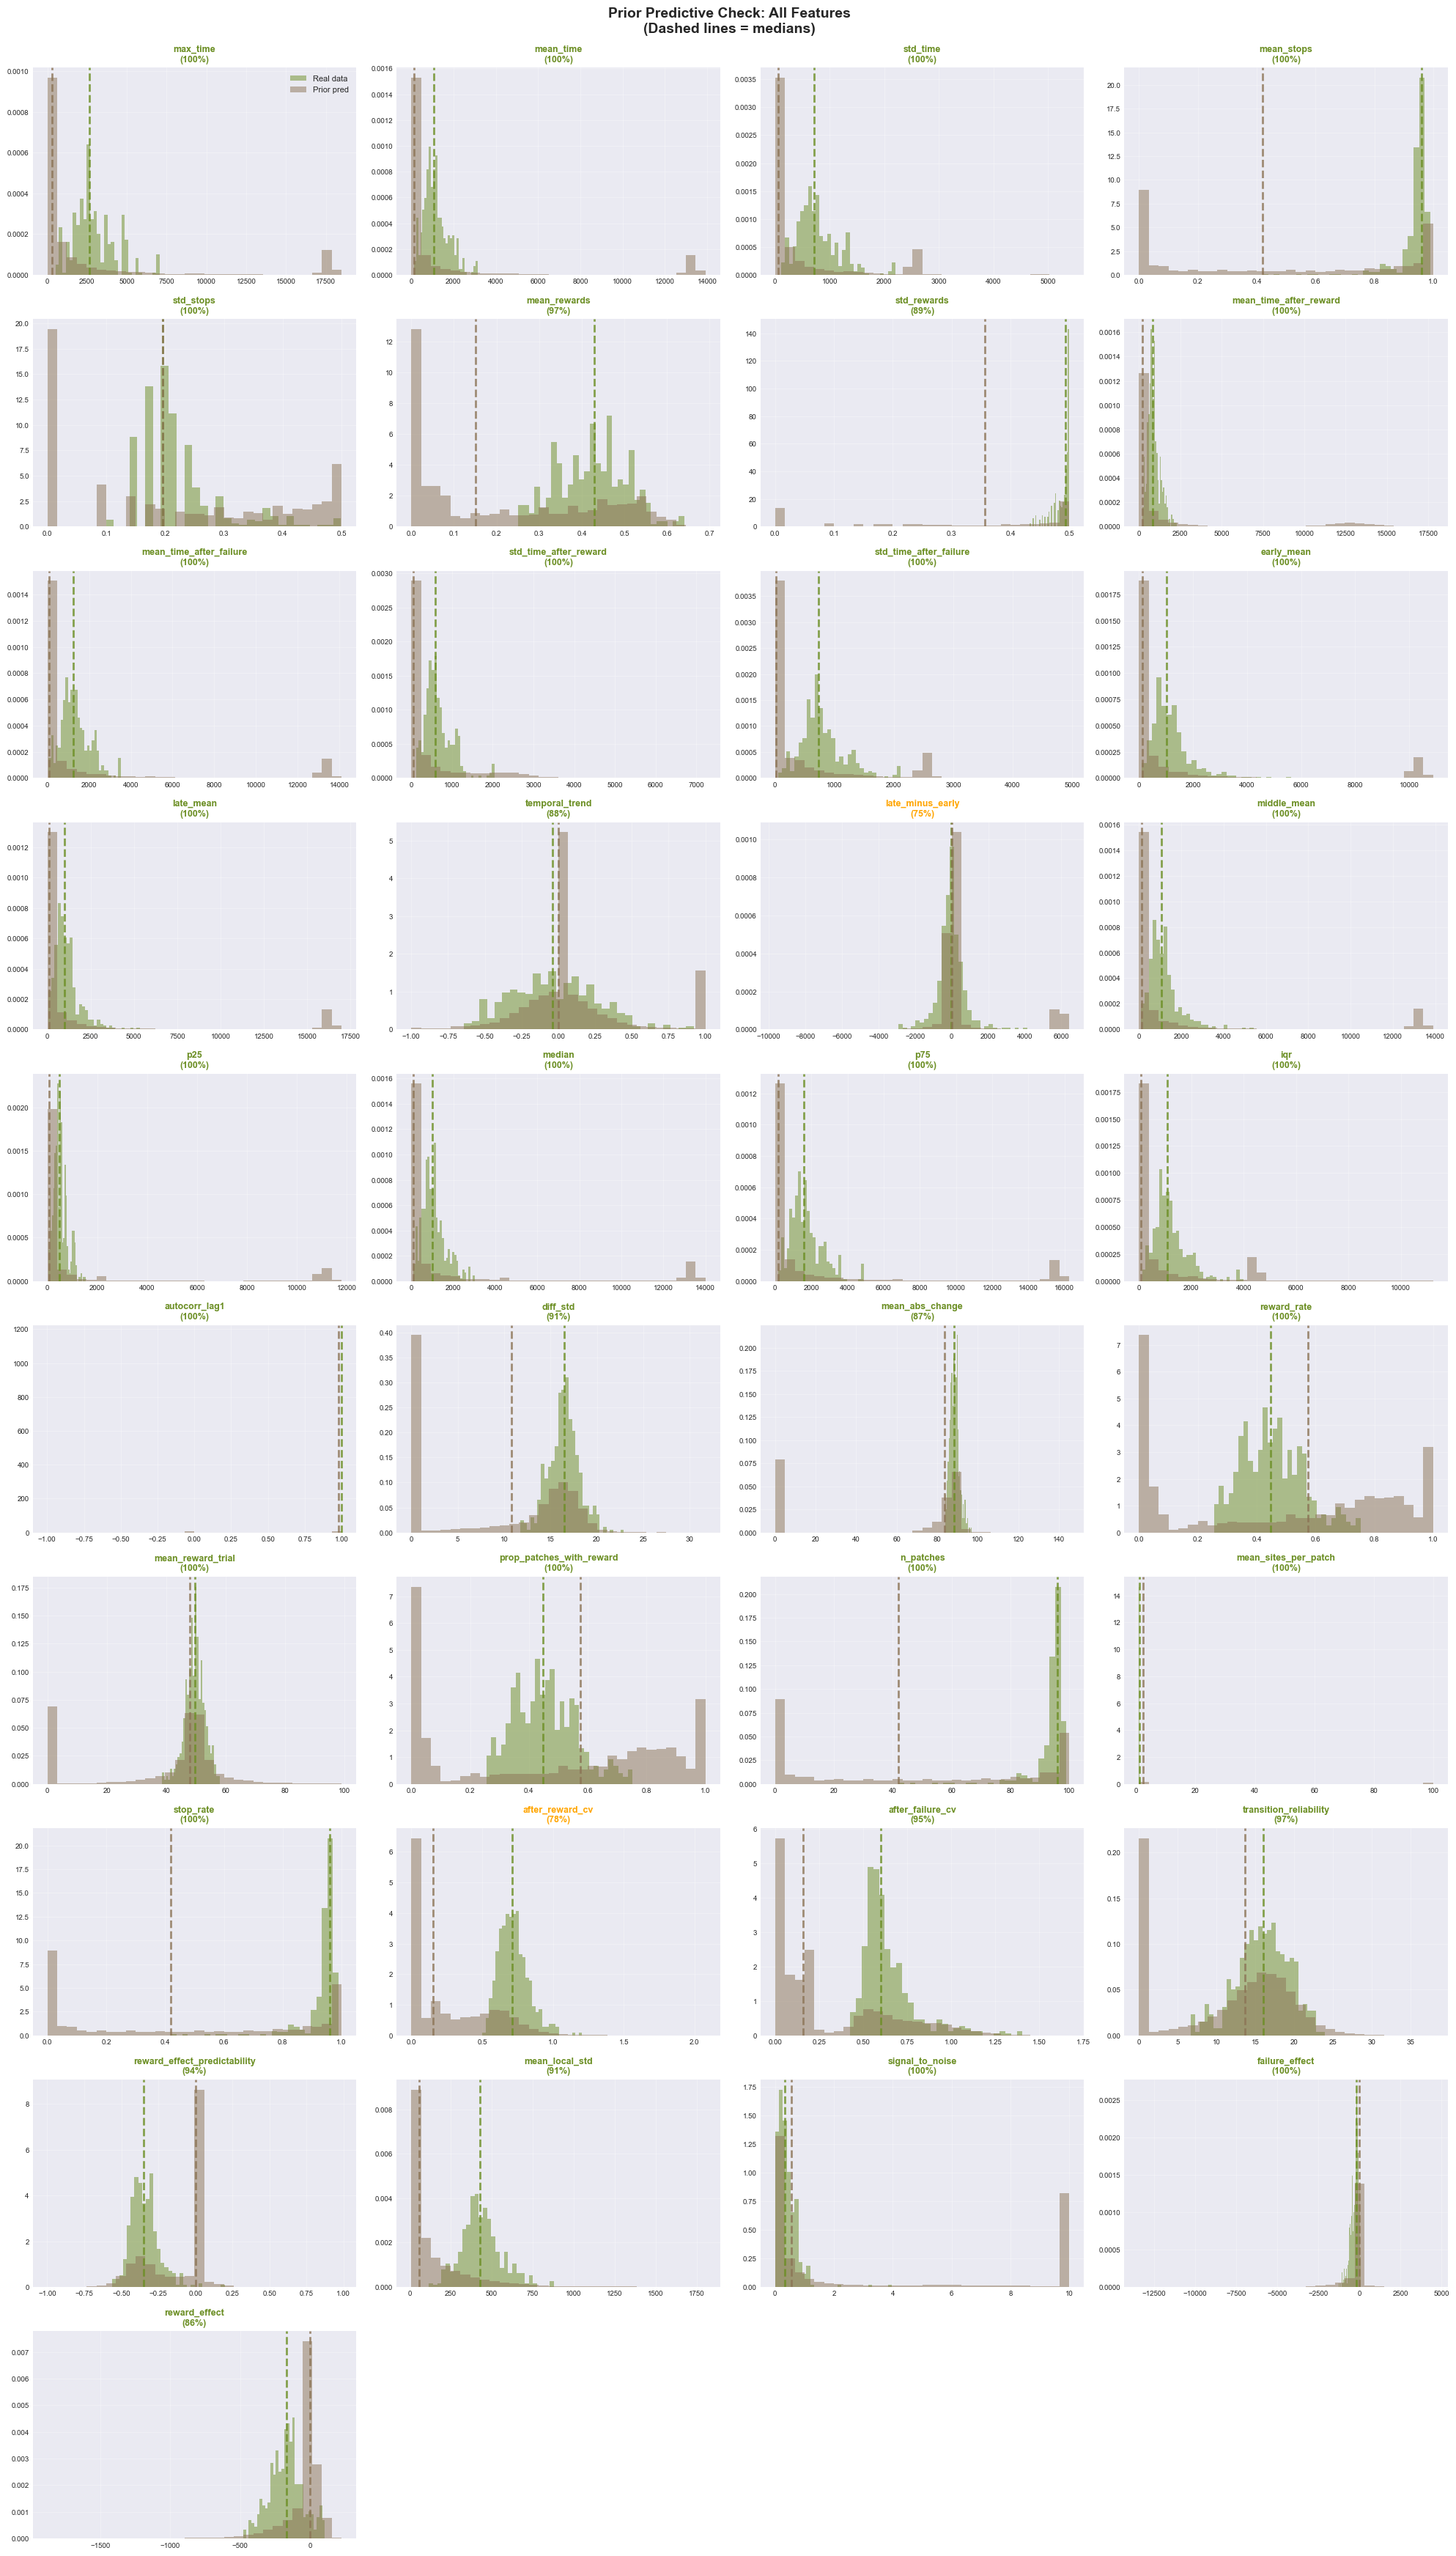

In [8]:
# %% Section 3.4: Visualize Prior Predictive Distributions

print(f"\n{'='*70}")
print(f"Section 3.4: Visualize Prior Predictive Distributions")
print(f"{'='*70}\n")

# Create comprehensive visualization
n_features = len(FEATURE_NAMES)
n_cols = 4
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3.5))
axes = axes.flatten()

# Earthy color palette
earth_real = '#6B8E23'      # olive green for real data
earth_sim = '#8B7355'       # brown for simulated data
earth_overlap = '#9CAF88'   # sage for overlap

print(f"Creating distribution plots for all {n_features} features...")

for i, feature_name in enumerate(FEATURE_NAMES):
    ax = axes[i]
    
    real_values = all_real_stats[:, i]
    sim_values = all_prior_stats[:, i]
    
    # Plot histograms
    ax.hist(real_values, bins=30, alpha=0.5, color=earth_real, 
            edgecolor='none', density=True, label='Real data')
    ax.hist(sim_values, bins=30, alpha=0.5, color=earth_sim, 
            edgecolor='none', density=True, label='Prior pred')
    
    # Add median lines
    ax.axvline(np.median(real_values), color=earth_real, 
               linestyle='--', linewidth=2, alpha=0.8)
    ax.axvline(np.median(sim_values), color=earth_sim, 
               linestyle='--', linewidth=2, alpha=0.8)
    
    # Title with coverage
    within_range = jnp.sum((real_values >= prior_percentiles['p05'][i]) & 
                           (real_values <= prior_percentiles['p95'][i]))
    coverage_pct = 100 * within_range / len(real_values)
    
    # Color title based on coverage
    if coverage_pct > 80:
        title_color = earth_real
    elif coverage_pct > 50:
        title_color = 'orange'
    else:
        title_color = 'red'
    
    ax.set_title(f"{feature_name}\n({coverage_pct:.0f}%)", 
                 fontsize=9, color=title_color, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.3)
    
    # Only show legend on first plot
    if i == 0:
        ax.legend(fontsize=8, loc='upper right')

# Hide extra subplots
for i in range(n_features, len(axes)):
    axes[i].axis('off')

plt.suptitle('Prior Predictive Check: All Features\n(Dashed lines = medians)', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()

# Save
plt.savefig(output_dir / 'prior_predictive_all_features.png', 
            dpi=150, bbox_inches='tight')
print(f"\n✓ Comprehensive feature plot saved to:")
print(f"  {output_dir / 'prior_predictive_all_features.png'}")

plt.show()

In [9]:
# %% Check outliers across all features

print(f"\n{'='*70}")
print(f"OUTLIER ANALYSIS ACROSS ALL FEATURES")
print(f"{'='*70}\n")

# For each feature, find cases where simulated exceeds real data range significantly
print(f"Checking features where simulated data exceeds real data range...\n")
print(f"{'Feature':<30} {'Real 99%':>10} {'Sim 99%':>10} {'Sim Max':>10} {'Outliers':>10}")
print(f"{'-'*72}")

outlier_features = []

for i, feature_name in enumerate(FEATURE_NAMES):
    real_p99 = jnp.percentile(all_real_stats[:, i], 99)
    real_max = jnp.max(all_real_stats[:, i])
    sim_p99 = jnp.percentile(all_prior_stats[:, i], 99)
    sim_max = jnp.max(all_prior_stats[:, i])
    
    # Count how many simulated samples exceed real 99th percentile
    n_outliers = jnp.sum(all_prior_stats[:, i] > real_p99)
    pct_outliers = 100 * n_outliers / len(all_prior_stats)
    
    # Flag if >10% of simulated data exceeds real 99th percentile
    if pct_outliers > 10:
        outlier_features.append((i, feature_name, pct_outliers))
        flag = "⚠"
    else:
        flag = ""
    
    # Only print features with notable outliers
    if pct_outliers > 5:
        print(f"{feature_name:<30} {real_p99:>10.1f} {sim_p99:>10.1f} {sim_max:>10.1f} {pct_outliers:>9.1f}% {flag}")

print(f"\n{'-'*72}")
print(f"\nFeatures with >10% outliers beyond real data 99th percentile:")
for i, name, pct in outlier_features:
    print(f"  {name}: {pct:.1f}%")
    
    # Show parameter correlations for this feature
    print(f"    Parameter correlations:")
    for j, param_name in enumerate(['drift', 'reward_bump', 'failure_bump', 'noise']):
        corr = jnp.corrcoef(all_prior_params[:, j], all_prior_stats[:, i])[0, 1]
        print(f"      {param_name}: {corr:>6.3f}")
    
    # Show example extreme parameter combinations
    extreme_idx = jnp.argsort(all_prior_stats[:, i])[-5:]  # Top 5 extreme values
    print(f"    Top 5 extreme cases:")
    for idx in extreme_idx:
        val = all_prior_stats[idx, i]
        theta = all_prior_params[idx]
        print(f"      {name}={val:.1f}: drift={theta[0]:.2f}, rew={theta[1]:.2f}, fail={theta[2]:.2f}, noise={theta[3]:.2f}")
    print()


OUTLIER ANALYSIS ACROSS ALL FEATURES

Checking features where simulated data exceeds real data range...

Feature                          Real 99%    Sim 99%    Sim Max   Outliers
------------------------------------------------------------------------
max_time                           7053.1    17941.4    18494.2      13.0% ⚠
mean_time                          3050.3    13509.5    13922.1      13.5% ⚠
std_time                           2139.3     3598.7     5386.8      12.7% ⚠
mean_stops                            1.0        1.0        1.0      13.4% ⚠
std_stops                             0.5        0.5        0.5      10.2% ⚠
mean_time_after_reward             2024.3    14341.2    17792.9      13.3% ⚠
mean_time_after_failure            3435.3    13587.8    14105.6      13.5% ⚠
std_time_after_reward              2000.7     3230.0     7223.6       8.2% 
std_time_after_failure             2072.8     3418.4     4951.9      12.7% ⚠
early_mean                         3674.8    10538.4  